Title: DSC 320 Math for Data Science Assignment 8.2 ; Author: Rachael Biegert ; Date: 9 May 2026 ; Modified By: Rachael Biegert ; Description: This program demonstrates the use of ; NumPy, matplotlib, pandas, and sklearn to solve equations, transformations, eigenvectors, and PCA, showing how these concepts build on each other and are applied in practical scenarios.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

##1)


In [25]:
# Define the matrix A
A = np.array([
    [27, -10,  4, -29],
    [-16,  5, -2,  18],
    [-17,  4, -2,  20],
    [-7,   2, -1,   8]
])
# Define vector b
B = np.array([1, -1, 0, 1])

# Solve Ax = b
x = np.linalg.solve(A, B)

print("Solution:", x)

Solution: [10.  3. -9.  7.]


##2)

In [26]:
# Define the transformation matrix A
A = np.array([
    [np.sqrt(2)/2, -np.sqrt(2)/2],
    [np.sqrt(2)/2,  np.sqrt(2)/2]
])

# Define vector x
x = np.array([2, -2])

# Apply the linear transformation T(x) = Ax
Tx = A @ x

# Print the transformed vector
print("T(x) =", Tx)

T(x) = [2.82842712 0.        ]


##b)


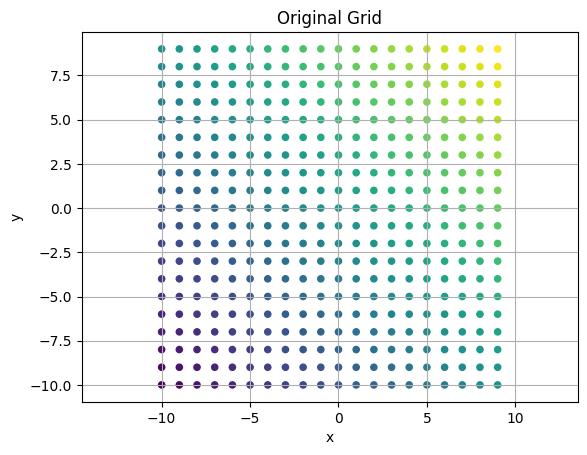

In [27]:
# Create x and y values for the grid
x_vals = np.arange(-10, 10, 1)
y_vals = np.arange(-10, 10, 1)

# Create a grid of points using meshgrid
xx, yy = np.meshgrid(x_vals, y_vals)

# Plot the original grid
plt.scatter(xx, yy, s=20, c=xx + yy)

# Add title and labels
plt.title("Original Grid")
plt.xlabel("x")
plt.ylabel("y")

# Keep the x and y axes on the same scale
plt.axis("equal")
plt.grid(True)
plt.show()



Shape of xy: (2, 400)
Shape of transformed points: (2, 400)


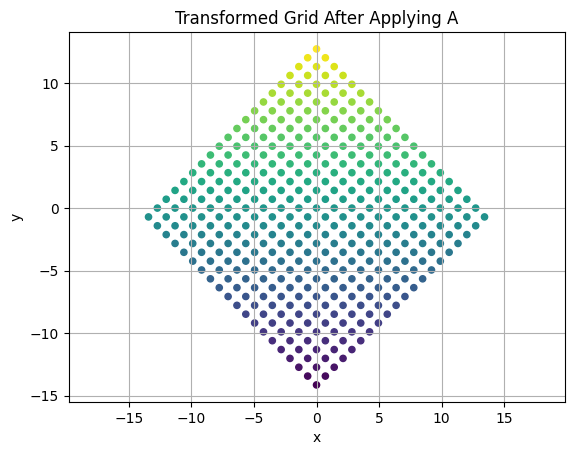

In [28]:
# Stack the grid points into a 2 x 400 matrix
# Each column represents one point/vector from the grid
xy = np.vstack([xx.flatten(), yy.flatten()])

# Check the shape
print("Shape of xy:", xy.shape)
# Apply the transformation matrix A to every point in the grid
trans = A @ xy

# Check that the transformed matrix still has 400 points
print("Shape of transformed points:", trans.shape)
# Reshape the transformed x-values and y-values back into grid form
xx_trans = trans[0].reshape(xx.shape)
yy_trans = trans[1].reshape(yy.shape)
# Plot the transformed grid
plt.scatter(xx_trans, yy_trans, s=20, c=xx + yy)

# Add title and labels
plt.title("Transformed Grid After Applying A")
plt.xlabel("x")
plt.ylabel("y")

# Keep the x and y axes on the same scale
plt.axis("equal")
plt.grid(True)
plt.show()

##c)

A good way to see this is with the vector from part (a). The original vector was:
x=[2−2]x =
\begin{bmatrix}
2 \\
-2
\end{bmatrix}x=[2−2​]
After applying the transformation, it became:
T(x)=[2.8280]T(x) =
\begin{bmatrix}
2.828 \\
0
\end{bmatrix}T(x)=[2.8280​]
This means the vector was rotated upward until it landed on the positive x-axis. The transformation does not stretch or shrink the vectors. It only changes their direction. Geometrically, this matrix performs a 45-degree counterclockwise rotation around the origin.

##3.


In [29]:
# Define matrix A
A = np.array([
    [4, 0, 1],
    [-1, -6, -2],
    [5, 0, 0]
])

print(A)

[[ 4  0  1]
 [-1 -6 -2]
 [ 5  0  0]]


##a)

In [30]:
vector_1 = np.array([1, 2, 3])

Avector_1 = A @ vector_1

print("A times vector_1 =", Avector_1)
print("vector_1 =", vector_1)

# Since [7, -19, 5] is not a scalar multiple of [1, 2, 3],
# v1 is not an eigenvector of A.

A times vector_1 = [  7 -19   5]
vector_1 = [1 2 3]


##b)

In [31]:
# Define the vector from part (b)
vector_2 = np.array([0, 1, 0])

# Multiply matrix A by vector v2
Avector_2 = A @ vector_2

# Print the result
print("A times vector_2 =", Avector_2)
print("vector_2 =", vector_2)

# Since A times v2 equals -6 times v2,
# v2 is an eigenvector of A.
# the eigenvalue is -6

A times vector_2 = [ 0 -6  0]
vector_2 = [0 1 0]


##c)

In [32]:
# Use NumPy to find the eigenvalues and eigenvectors of A
eigenvalues, eigenvectors = np.linalg.eig(A)

# Print the eigenvalues
print("Eigenvalues:",eigenvalues)

# Print the eigenvectors
print("Eigenvectors:", eigenvectors)


Eigenvalues: [-6.  5. -1.]
Eigenvectors: [[ 0.          0.69431384 -0.18493168]
 [ 1.         -0.18935832 -0.33287702]
 [ 0.          0.69431384  0.9246584 ]]


##4.

                        name  critic_score  user_score  total_shipped
0             Mario Kart Wii           8.2         9.1          37.14
1          Wii Sports Resort           8.0         8.8          33.09
2      New Super Mario Bros.           9.1         8.1          30.80
3  New Super Mario Bros. Wii           8.6         9.2          30.22
4              Mario Kart DS           9.1         9.4          23.60


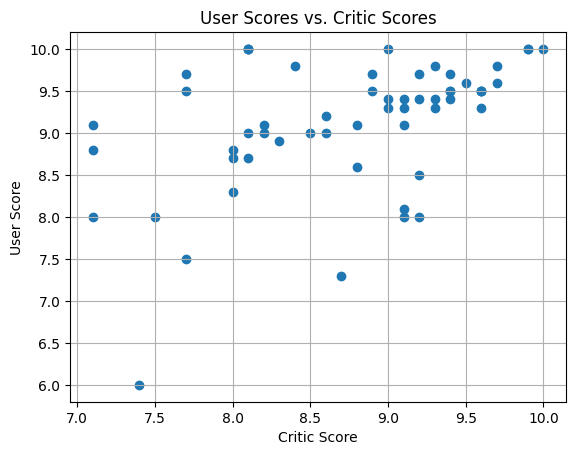

In [33]:
# Read in the video game data
df = pd.read_csv("/content/drive/MyDrive/video_game_data.csv")

# Look at the first few rows to make sure the file loaded correctly
print(df.head())

# Create a scatterplot of user scores versus critic scores
plt.scatter(df["critic_score"], df["user_score"])

# Add labels and title
plt.xlabel("Critic Score")
plt.ylabel("User Score")
plt.title("User Scores vs. Critic Scores")

# Add grid to make the graph easier to read
plt.grid(True)

# Show the scatterplot
plt.show()

Principal component directions:
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]
Explained variance ratio:
[0.72933479 0.27066521]


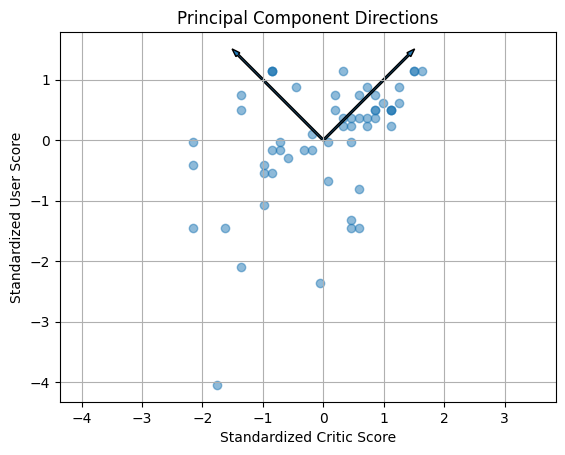

In [34]:
# Select only the two columns we are using for PCA
scores = df[["critic_score", "user_score"]]

# Standardize the data so both variables are on a similar scale
scaler = StandardScaler()
scores_scaled = scaler.fit_transform(scores)

# Create the PCA model with 2 components
pca = PCA(n_components=2)

# Fit PCA to the standardized score data
pca.fit(scores_scaled)

# Print the principal component directions
print("Principal component directions:")
print(pca.components_)

# Print how much variation each component explains
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

# Create a scatterplot of the standardized scores
plt.scatter(scores_scaled[:, 0], scores_scaled[:, 1], alpha=0.5)

# Store the principal component directions
components = pca.components_

# Draw the first principal component direction
plt.arrow(
    0, 0,
    components[0, 0] * 2,
    components[0, 1] * 2,
    width=0.03,
    label="PC1"
)

# Draw the second principal component direction
plt.arrow(
    0, 0,
    components[1, 0] * 2,
    components[1, 1] * 2,
    width=0.03,
    label="PC2"
)

# Add labels and title
plt.xlabel("Standardized Critic Score")
plt.ylabel("Standardized User Score")
plt.title("Principal Component Directions")

# Keep the scale even so directions are not distorted
plt.axis("equal")
plt.grid(True)

# Show the graph
plt.show()